<a href="https://colab.research.google.com/github/Sharmika-18/Task1/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


**Data Loading and Cleaning**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("retail_sales_dataset.csv")

# Display first rows
print(df.head())

# Check info
print(df.info())

# Check missing values
print(df.isnull().sum())

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check numeric columns
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price per Unit'] = pd.to_numeric(df['Price per Unit'], errors='coerce')
df['Total Amount'] = pd.to_numeric(df['Total Amount'], errors='coerce')

# Fill missing numeric values with median
df.fillna(df.median(numeric_only=True), inplace=True)

print("Cleaning Done")


   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   obj

**Descriptive Statistics**

In [ ]:
print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode().iloc[0])
print("\nStandard Deviation:\n", df.std(numeric_only=True))


Mean:
 Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
 Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
 Transaction ID                        1
Date                2023-05-16 00:00:00
Customer ID                     CUST001
Gender                           Female
Age                                43.0
Product Category               Clothing
Quantity                            4.0
Price per Unit                     50.0
Total Amount                       50.0
Name: 0, dtype: object

Standard Deviation:
 Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


**Time Series Analysis**

/tmp/ipython-input-3807023659.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Total Amount'].resample('M').sum()


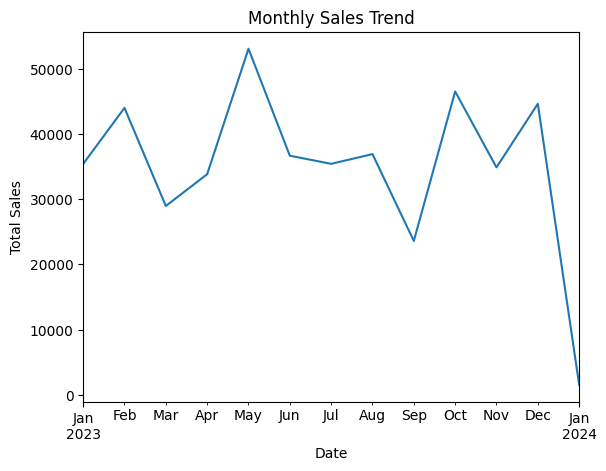

In [ ]:
# Set Date as index
df.set_index('Date', inplace=True)

# Monthly sales
monthly_sales = df['Total Amount'].resample('M').sum()

# Plot
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


**Customer & Product Analysis**

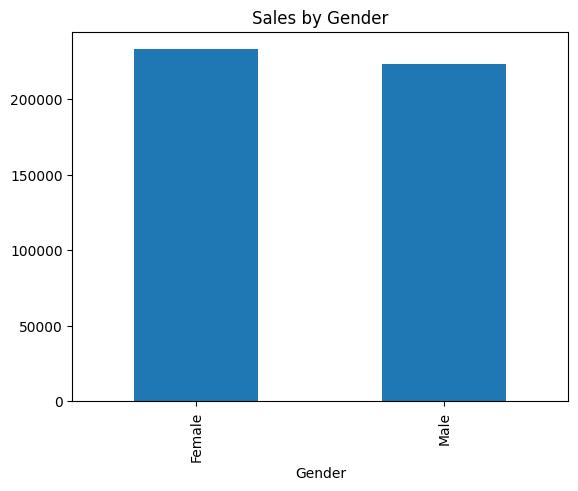

In [ ]:
#gender wise sales
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure()
gender_sales.plot(kind='bar')
plt.title("Sales by Gender")
plt.show()


/tmp/ipython-input-3008705265.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age Group')['Total Amount'].sum()


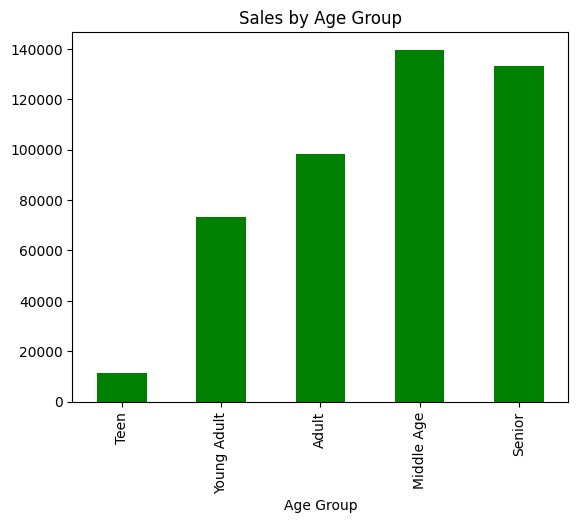

In [ ]:
#age wise
bins = [0, 18, 25, 35, 50, 100]
labels = ['Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_sales = df.groupby('Age Group')['Total Amount'].sum()

plt.figure()
age_sales.plot(kind='bar',color='green')
plt.title("Sales by Age Group")
plt.show()


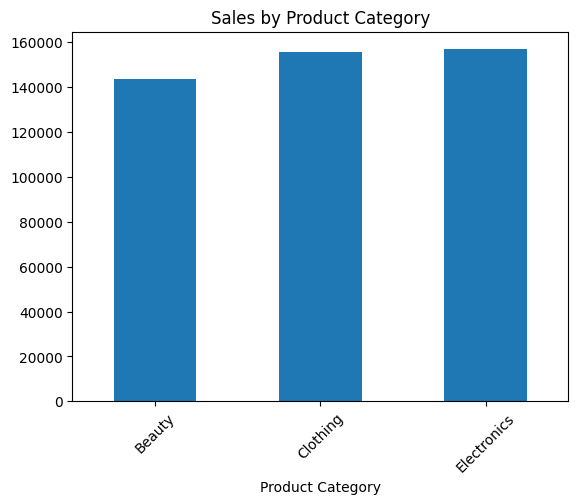

In [ ]:
#product category
category_sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xticks(rotation=45)
plt.show()


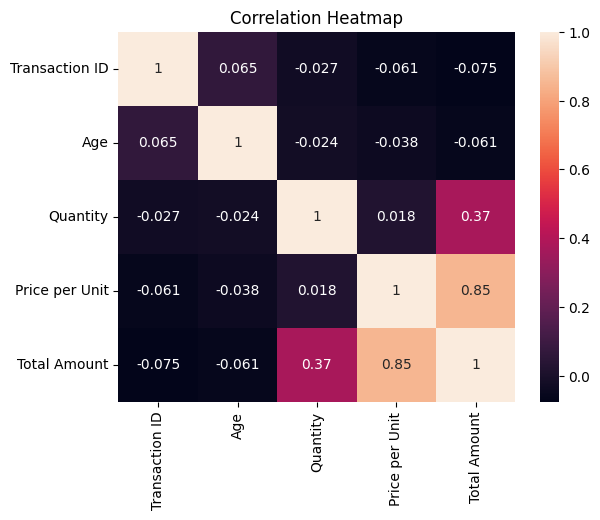

In [ ]:
#heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()
